In [4]:
import numpy as np
import pandas as pd
import tqdm as tqdm
import numpy

In [2]:
import torch
import sys

In [3]:
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset
from sklearn.model_selection import train_test_split as tt_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as mse
from scipy.stats import bernoulli as bern

In [5]:
pd.set_option('display.max_rows', 2600)
numpy.set_printoptions(threshold=sys.maxsize)

## Processing the data of the team ratings

In [6]:
team_ratings = pd.read_csv('Datasets/male_teams.csv')

In [7]:
# we first process the team ratings data, by removing uneccessary features like the team url, and also remove clubs 
# so that only national teams remain

# first we only keep the the features we are interested in
labels_to_drop = list(team_ratings.columns)
keep_labs = ['team_name', 'league_name', 'overall', 'attack', 'midfield', 'defence', 'nationality_id',
                      'international_prestige', 'starting_xi_average_age', 'whole_team_average_age']
for lab in keep_labs:
    labels_to_drop.remove(lab)

team_ratings_new = team_ratings.drop(labels_to_drop, axis = 1)
old_index = list(range(0,6947))
team_ratings.insert(0, 'old_index', old_index)

#old_versions = 
#team_ratings_new = team_ratings_new.drop()

# here we remove the football clubs, meaning non national teams
league_list = team_ratings['league_name']
non_international = league_list[league_list != 'Friendly International']
non_international_u = list(set(non_international))

ind_to_remove = []
for i in old_index:
    if league_list[i] in non_international_u:
        ind_to_remove.append(i)

team_ratings_almost_clean = team_ratings_new.drop(ind_to_remove)
team_ratings_almost_clean = team_ratings_almost_clean.reset_index(drop = True)

# finally we remove non-european nations
new_index = list(range(0,436))
nat_id_list = list(team_ratings_almost_clean['nationality_id'])
more_to_remove = []

# the dataset contains also ratings from old FIFA games so we remove duplicate ratings of teams
team_ratings_clean = team_ratings_almost_clean.drop(more_to_remove)
team_ratings_clean = team_ratings_clean.reset_index(drop = True)
team_ratings_finally_n = team_ratings_clean.drop_duplicates(subset = 'team_name')
team_ratings_finally = team_ratings_finally_n.drop('nationality_id', axis = 1)
team_ratings_finally = team_ratings_finally.reset_index(drop = True)

# The Kim Jong Un is not gonna like this one
team_ratings_finally['team_name'] = team_ratings_finally['team_name'].str.replace('Korea Republic', 'South Korea')


# as some of the teams participating at the EUROS are still missing we add them manually
Serbia = ['Serbia', 'Friendly International', 74, 75, 73, 70, 4, 27, 29]
Georgia = ['Georgia', 'Friendly International', 68, 68, 69, 67, 2, 25, 28]
Slovakia = ['Slovakia', 'Friendly International', 69, 70, 68, 68, 3, 24, 27.5]
Albania = ['Albania', 'Friendly International', 69, 70, 69, 68, 2, 24, 23.9]

team_ratings_finally.loc[len(team_ratings_finally.index)] = Serbia
team_ratings_finally.loc[len(team_ratings_finally.index)] = Georgia
team_ratings_finally.loc[len(team_ratings_finally.index)] = Slovakia
team_ratings_finally.loc[len(team_ratings_finally.index)] = Albania

# finally for later we code each nation with an integer
##encoded_teams = []
#for team in list(team_ratings_finally['team_name']):
#    encoded_teams.append(encoder(team))

#team_ratings_finally.insert(9, 'team_number', encoded_teams)

In [8]:
# for later to enumerate the teams

team_ratings_copy = team_ratings_finally
team_ratings_copy.insert(0, 'index_number', list(range(0, len(team_ratings_finally))))
team_ratings_finally = team_ratings_finally.drop(['index_number'], axis = 1)

team_ratings_finally

,team_name,league_name,overall,attack,midfield,defence,international_prestige,starting_xi_average_age,whole_team_average_age
0,England,Friendly International,85,86,83,83,8,27.45,26.62
1,France,Friendly International,84,85,85,83,10,26.73,25.77
2,Germany,Friendly International,84,84,83,83,10,28.18,26.81
3,Portugal,Friendly International,84,86,84,83,8,28.82,27.04
4,Italy,Friendly International,83,82,83,82,9,26.91,25.85
5,Spain,Friendly International,83,82,85,82,9,26.45,26.15
6,Argentina,Friendly International,83,85,83,83,9,28.64,27.96
7,Netherlands,Friendly International,82,82,81,83,8,27.45,26.35
8,Belgium,Friendly International,81,82,80,77,8,27.73,26.23
9,Croatia,Friendly International,79,78,82,78,6,28.45,27.31


In [9]:
def get_index(team_name):
    team_number = list(team_ratings_copy[team_ratings_copy['team_name'] == team_name]['index_number'])[0]
    return team_number

## Processing the match result data

In [10]:
results = pd.read_csv('Datasets/results.csv')

In [11]:
# we first take all matches that were not from a FIFA World Cup, a UEFA Euro, or a UEFA Euro qualifier
non_wc_eu = []
wc_eu = ['UEFA Euro', 'FIFA World Cup', 'UEFA Euro qualification']
tournament = list(results['tournament'])
for i in range(0,len(results)):
    if tournament[i] not in wc_eu:
        non_wc_eu.append(i)

results_wc_eu = results.drop(non_wc_eu)

# due to historical inconstistencies with the names, we rename some teams so that we can use the ratings 
results_wc_eu['home_team'] = results_wc_eu['home_team'].str.replace('Yugoslavia', 'Serbia')
results_wc_eu['away_team'] = results_wc_eu['away_team'].str.replace('Yugoslavia', 'Serbia')
results_wc_eu['home_team'] = results_wc_eu['home_team'].str.replace('Czechoslovakia', 'Czech Republic')
results_wc_eu['away_team'] = results_wc_eu['away_team'].str.replace('Czechoslovakia', 'Czech Republic')

# we now take out all the matches were a team played for which we do not have a rating
needed_nations = list(team_ratings_finally['team_name'])
len_results = len(results_wc_eu)
games_to_remove = []
home_team = list(results_wc_eu['home_team'])
away_team = list(results_wc_eu['away_team'])
for i in range(0, len(results_wc_eu)):
    if home_team[i] not in needed_nations or away_team[i] not in needed_nations:
        games_to_remove.append(i)
        
results_wc_eu = results_wc_eu.reset_index(drop = True)
results_wc_eu_cut = results_wc_eu.drop(games_to_remove)
results_wc_eu_cut = results_wc_eu_cut.reset_index(drop = True)
results_wc_eu_finally = results_wc_eu_cut.drop(list(range(2492, 2528)))

In [12]:
results_wc_eu_finally

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True
2,1930-07-14,Brazil,Serbia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True
3,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
4,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True
5,1930-07-16,Chile,Mexico,3.0,0.0,FIFA World Cup,Montevideo,Uruguay,True
6,1930-07-17,Bolivia,Serbia,0.0,4.0,FIFA World Cup,Montevideo,Uruguay,True
7,1930-07-17,Paraguay,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
8,1930-07-18,Uruguay,Peru,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,False
9,1930-07-19,Argentina,Mexico,6.0,3.0,FIFA World Cup,Montevideo,Uruguay,True


## Transform match result dataframe into numpy array

In [13]:
results_wc_eu_num1 = results_wc_eu_finally
results_wc_eu_num1['neutral'] = results_wc_eu_num1['neutral'].astype(int)
results_wc_eu_num1['neutral'] = results_wc_eu_num1['neutral'].astype(int)
results_wc_eu_num1 = results_wc_eu_num1.drop(['city', 'country', 'tournament', 'date'], axis = 1)

home_nr = []
away_nr = []
home_team_c = list(results_wc_eu_num1['home_team'])
away_team_c = list(results_wc_eu_num1['away_team'])

for i in range(0, len(results_wc_eu_num1)):
    home_nr.append(get_index(home_team_c[i]))
    away_nr.append(get_index(away_team_c[i]))
    
results_wc_eu_num1.insert(0, 'away_number', away_nr)
results_wc_eu_num1.insert(0, 'home_number', home_nr)

results_wc_eu_num1

,home_number,away_number,home_team,away_team,home_score,away_score,neutral
0,8,20,Belgium,United States,0.0,3.0,1
1,1,13,France,Mexico,4.0,1.0,1
2,30,56,Brazil,Serbia,1.0,2.0,1
3,48,25,Peru,Romania,1.0,3.0,1
4,6,1,Argentina,France,1.0,0.0,1
5,41,13,Chile,Mexico,3.0,0.0,1
6,51,56,Bolivia,Serbia,0.0,4.0,1
7,44,20,Paraguay,United States,0.0,3.0,1
8,37,48,Uruguay,Peru,1.0,0.0,0
9,6,13,Argentina,Mexico,6.0,3.0,1


In [14]:
results_wc_eu_num2 = results_wc_eu_num1.drop(['home_team', 'away_team'], axis = 1)
np_results_wc_eu = results_wc_eu_num2.to_numpy()

np_results_wc_eu

array([[ 8., 20.,  0.,  3.,  1.],
       [ 1., 13.,  4.,  1.,  1.],
       [30., 56.,  1.,  2.,  1.],
       [48., 25.,  1.,  3.,  1.],
       [ 6.,  1.,  1.,  0.,  1.],
       [41., 13.,  3.,  0.,  1.],
       [51., 56.,  0.,  4.,  1.],
       [44., 20.,  0.,  3.,  1.],
       [37., 48.,  1.,  0.,  0.],
       [ 6., 13.,  6.,  3.,  1.],
       [41.,  1.,  1.,  0.,  1.],
       [ 8., 44.,  0.,  1.,  1.],
       [51., 30.,  0.,  4.,  1.],
       [37., 25.,  4.,  0.,  0.],
       [ 6., 41.,  3.,  1.,  1.],
       [ 6., 20.,  6.,  1.,  1.],
       [37., 56.,  6.,  1.,  0.],
       [37.,  6.,  4.,  2.,  0.],
       [ 6., 17.,  2.,  3.,  1.],
       [31.,  1.,  3.,  2.,  1.],
       [ 8.,  2.,  2.,  5.,  1.],
       [30.,  5.,  1.,  3.,  1.],
       [14., 25.,  2.,  1.,  1.],
       [45., 21.,  2.,  4.,  1.],
       [ 4., 20.,  7.,  1.,  0.],
       [ 7., 39.,  2.,  3.,  1.],
       [31., 21.,  2.,  1.,  1.],
       [14., 39.,  3.,  2.,  1.],
       [ 2., 17.,  2.,  1.,  1.],
       [ 4.,  

## Transform team rating dataframe into numpy array

In [16]:
team_ratings_num1 = team_ratings_copy.drop(['team_name', 'league_name'], axis = 1)
np_team_ratings = team_ratings_num1.to_numpy()

np_team_ratings

array([[ 0.  , 85.  , 86.  , 83.  , 83.  ,  8.  , 27.45, 26.62],
       [ 1.  , 84.  , 85.  , 85.  , 83.  , 10.  , 26.73, 25.77],
       [ 2.  , 84.  , 84.  , 83.  , 83.  , 10.  , 28.18, 26.81],
       [ 3.  , 84.  , 86.  , 84.  , 83.  ,  8.  , 28.82, 27.04],
       [ 4.  , 83.  , 82.  , 83.  , 82.  ,  9.  , 26.91, 25.85],
       [ 5.  , 83.  , 82.  , 85.  , 82.  ,  9.  , 26.45, 26.15],
       [ 6.  , 83.  , 85.  , 83.  , 83.  ,  9.  , 28.64, 27.96],
       [ 7.  , 82.  , 82.  , 81.  , 83.  ,  8.  , 27.45, 26.35],
       [ 8.  , 81.  , 82.  , 80.  , 77.  ,  8.  , 27.73, 26.23],
       [ 9.  , 79.  , 78.  , 82.  , 78.  ,  6.  , 28.45, 27.31],
       [10.  , 79.  , 76.  , 80.  , 79.  ,  6.  , 27.27, 26.35],
       [11.  , 78.  , 79.  , 75.  , 79.  ,  3.  , 26.73, 26.69],
       [12.  , 77.  , 85.  , 75.  , 74.  ,  5.  , 28.27, 26.92],
       [13.  , 77.  , 77.  , 76.  , 74.  ,  7.  , 26.82, 26.38],
       [14.  , 76.  , 76.  , 76.  , 75.  ,  5.  , 27.  , 26.69],
       [15.  , 76.  , 91.

## Create dataframe and np array for group stage matches

In [17]:
results_wc_eu_cut.fillna(0)
results_to_predict = results_wc_eu_cut[2492:2528] 
results_to_predict = results_to_predict.fillna(0)
results_to_predict = results_to_predict.drop(['city', 'country', 'tournament', 'date'], axis = 1)
results_to_predict


,home_team,away_team,home_score,away_score,neutral
2492,Germany,Scotland,0.0,0.0,False
2493,Hungary,Switzerland,0.0,0.0,True
2494,Spain,Croatia,0.0,0.0,True
2495,Italy,Albania,0.0,0.0,True
2496,Slovenia,Denmark,0.0,0.0,True
2497,Serbia,England,0.0,0.0,True
2498,Poland,Netherlands,0.0,0.0,True
2499,Austria,France,0.0,0.0,True
2500,Romania,Ukraine,0.0,0.0,True
2501,Belgium,Slovakia,0.0,0.0,True


In [52]:
len(results_to_predict)

36

In [66]:
results_to_predict_num1 = results_to_predict
results_to_predict_num1['neutral'] = results_to_predict_num1['neutral'].astype(int)
results_to_predict_num1['neutral'] = results_to_predict_num1['neutral'].astype(int)
results_to_predict_num1

,home_team,away_team,home_score,away_score,neutral
2492,Germany,Scotland,0.0,0.0,0
2493,Hungary,Switzerland,0.0,0.0,1
2494,Spain,Croatia,0.0,0.0,1
2495,Italy,Albania,0.0,0.0,1
2496,Slovenia,Denmark,0.0,0.0,1
2497,Serbia,England,0.0,0.0,1
2498,Poland,Netherlands,0.0,0.0,1
2499,Austria,France,0.0,0.0,1
2500,Romania,Ukraine,0.0,0.0,1
2501,Belgium,Slovakia,0.0,0.0,1


In [67]:
home_nr_pred = []
away_nr_pred = []
home_team_c_pred = list(results_to_predict_num1['home_team'])
away_team_c_pred = list(results_to_predict_num1['away_team'])

for i in range(0, len(results_to_predict_num1)):
    home_nr_pred.append(get_index(home_team_c_pred[i]))
    away_nr_pred.append(get_index(away_team_c_pred[i]))

results_to_predict_num1.insert(0, 'away_number', away_nr_pred)
results_to_predict_num1.insert(0, 'home_number', home_nr_pred)
results_to_predict_num1 = results_to_predict_num1.drop(['home_team', 'away_team'], axis = 1)
results_to_predict_num1 = results_to_predict_num1.drop(['home_score', 'away_score'], axis = 1)
np_results_to_predict = results_to_predict_num1.to_numpy()

In [68]:
np_results_to_predict

array([[ 2, 16,  0],
       [21, 39,  1],
       [ 5,  9,  1],
       [ 4, 59,  1],
       [49, 10,  1],
       [56,  0,  1],
       [12,  7,  1],
       [31,  1,  1],
       [25, 19,  1],
       [ 8, 58,  1],
       [40, 57,  1],
       [ 3, 14,  1],
       [ 2, 21,  0],
       [16, 39,  1],
       [ 9, 59,  1],
       [ 5,  4,  1],
       [49, 56,  1],
       [10,  0,  1],
       [12, 31,  1],
       [ 7,  1,  1],
       [58, 19,  1],
       [ 8, 25,  1],
       [57, 14,  1],
       [40,  3,  1],
       [ 2, 39,  0],
       [16, 21,  1],
       [59,  5,  1],
       [ 9,  4,  1],
       [ 0, 49,  1],
       [10, 56,  1],
       [ 7, 31,  1],
       [ 1, 12,  1],
       [58, 25,  1],
       [19,  8,  1],
       [57,  3,  1],
       [14, 40,  1]])

## Training with Linear Regression and  Neural Network

In [42]:
class Euro2024_new:
    
    def __init__(self, ratings, results):
        self.ratings = ratings
        self.results = results
        self.X = np.zeros((np.shape(results)[0], 2*np.shape(ratings)[1] - 1)) # ratings of the teams of the corresponding result
        self.Y = results[:, 2:4] # results of the matches
        self.labels = np.zeros(np.shape(results)[0])
        self.Z = np.zeros((np.shape(results)[0], 2*(np.shape(ratings)[1] - 1)))
        self.tensored = False
        self.X_created = False
        
    def create_X(self):
        self.X_created = True
        for row in range(0, np.shape(self.X)[0]):
            ij = self.results[row, 0:2]
            #print(ij)
            ratings_ij = list(self.ratings[int(ij[0]), 1:]) + list(self.ratings[int(ij[1]), 1:])
            ratings_ij.append(self.results[row, -1]) # value 0/1 if played on neutral ground FALSE/TRUE
            ratings_ij = np.asarray(ratings_ij)
            self.X[row] = ratings_ij # ratings of the teams of the corresponding result
    
    def create_labels(self):
        for row in range(np.shape(self.labels)[0]):
            if self.Y[row,0] == self.Y[row,1]:
                res = 0
            elif self.Y[row,0] > self.Y[row,1]:
                res = 1
            elif self.Y[row,0] < self.Y[row,1]:
                res = 2
            self.labels[row] = res
    
    def double_up(self):
        self.X_flip = np.zeros(np.shape(self.X))
        self.Y_flip = np.zeros(np.shape(self.Y))
        for row in range(0, np.shape(self.X)[0]):
            ij = self.results[row, 0:2]
            ij[0], ij[1] = ij[1], ij[0] 
            self.Y_flip[row] = [self.Y[row, 1], self.Y[row, 0]]
            #print(ij)
            ratings_ij = list(self.ratings[int(ij[0]), 1:]) + list(self.ratings[int(ij[1]), 1:])
            ratings_ij.append(self.results[row, -1]) # value 0/1 if played on neutral ground FALSE/TRUE
            ratings_ij = np.asarray(ratings_ij)
            self.X_flip[row] = ratings_ij # ratings of the teams of the corresponding result
            self.X_double = np.vstack((self.X, self.X_flip))
            self.Y_double = np.vstack((self.Y, self.Y_flip))
    
    def rating_diff(self):
        self.X_diff = np.zeros((np.shape(self.X)[0], 8))
        for row in range(0, np.shape(self.X)[0]):
            ij = self.results[row, 0:2]
            diff_ratings_ij = self.ratings[int(ij[0]), 1:] - self.ratings[int(ij[1]), 1:]
            diff_ratings_ij = np.append(diff_ratings_ij, self.results[row, -1])
            self.X_diff[row] = diff_ratings_ij
    
    def data_split(self):
        self.X_train, self.X_test, self.Y_train, self.Y_test = tt_split(self.X, self.Y, test_size = 0.2)
        self.X_train = torch.from_numpy(self.X_train)
        self.X_test = torch.from_numpy(self.X_test)
        self.Y_train = torch.from_numpy(self.Y_train)
        self.Y_test = torch.from_numpy(self.Y_test)
        self.tensored = True
      
    def data_split_np(self):
        self.X_train, self.X_test, self.Y_train, self.Y_test = tt_split(self.X, self.Y, test_size = 0.2)
    
    def data_split_svm(self):
        self.X_train, self.X_test, self.labels_train, self.labels_test = tt_split(self.X, self.labels, test_size = 0.2)
    
    def data_split_double(self):
        self.X_train, self.X_test, self.Y_train, self.Y_test = tt_split(self.X_double, self.Y_double, test_size = 0.2)
        self.X_train = torch.from_numpy(self.X_train)
        self.X_test = torch.from_numpy(self.X_test)
        self.Y_train = torch.from_numpy(self.Y_train)
        self.Y_test = torch.from_numpy(self.Y_test)
        self.tensored = True
    
    def data_split_diff(self):
        self.X_train, self.X_test, self.Y_train, self.Y_test = tt_split(self.X_diff, self.Y, test_size = 0.2)
        self.X_train = torch.from_numpy(self.X_train)
        self.X_test = torch.from_numpy(self.X_test)
        self.Y_train = torch.from_numpy(self.Y_train)
        self.Y_test = torch.from_numpy(self.Y_test)
        self.tensored = True

    def data_load(self):
        if self.tensored == False:
            print('Please tensor the data first using data_split')
        else:
            self.train = TensorDataset(self.X_train, self.Y_train)
            self.test = TensorDataset(self.X_test, self.Y_test)
            self.train_dataloader = DataLoader(self.train, batch_size = 60, shuffle = True)
            self.test_dataloader = DataLoader(self.test, batch_size = 60, shuffle = True)
    
    
            
        
        

In [217]:
euro_svm = Euro2024_new(np_team_ratings,np_results_wc_eu)
euro_svm.create_X()
euro_svm.create_labels()
euro_svm.data_split_svm()
rf_clf = RandomForestClassifier(max_depth = 8, random_state = 0, criterion = 'entropy')
rf_clf.fit(euro_svm.X_train, euro_svm.labels_train)
#print(rf_clf.predict(euro_svm.X_test))
rf_clf.score(euro_svm.X_test, euro_svm.labels_test)

0.5430861723446894

In [149]:
euro_svm = Euro2024_new(np_team_ratings,np_results_wc_eu)
euro_svm.create_X()
euro_svm.create_labels()
euro_svm.data_split_svm()
clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))
clf.fit(euro_svm.X_train, euro_svm.labels_train)
#print(clf.predict(euro_svm.X_test))
clf.score(euro_svm.X_test, euro_svm.labels_test)

0.5270541082164328

499


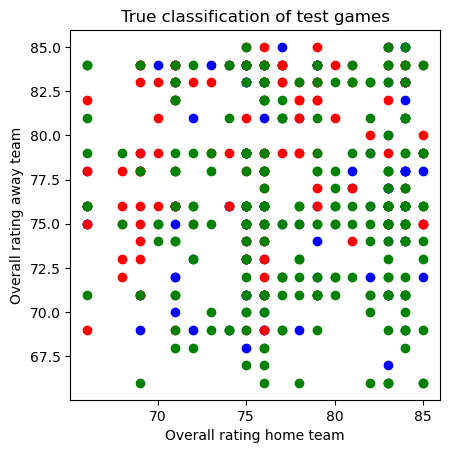

14


In [225]:
svm_ov_t = np.zeros((np.shape(euro_svm.X_test)[0], 2))
svm_ov_t[:,0] = euro_svm.X_test[:,0]
svm_ov_t[:,1] = euro_svm.X_test[:,7]
#svm_ov_and_labels[:,2] = euro_svm.labels_train

blue_dots_t = svm_ov_t[euro_svm.labels_test == 0]
green_dots_t = svm_ov_t[euro_svm.labels_test == 1]
red_dots_t = svm_ov_t[euro_svm.labels_test == 2]

print(len(red_dots_t)+len(green_dots_t) + len(blue_dots_t))
plt.scatter(blue_dots_t[:,0],blue_dots_t[:,1], c = 'b', label = 'draw')
plt.scatter(red_dots_t[:,0], red_dots_t[:,1], c = 'r', label = 'away win')
plt.scatter(green_dots_t[:,0], green_dots_t[:,1], c = 'g', label = 'home win')
plt.title('True classification of test games')
plt.xlabel('Overall rating home team')
plt.ylabel('Overall rating away team')
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
#plt.legend(bbox_to_anchor=(1, 1))

plt.show()
print(len(blue_dots_p))

1993


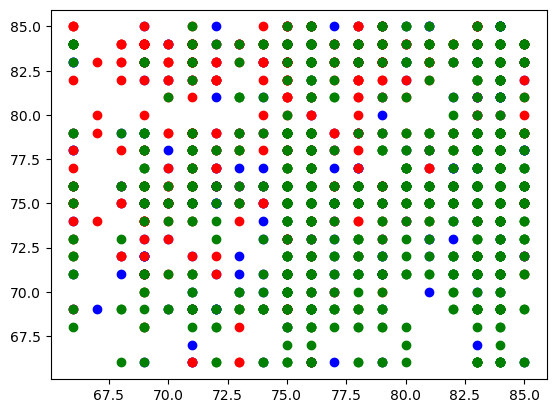

573


In [170]:
svm_ov_and_labels = np.zeros((np.shape(euro_svm.X_train)[0], 2))
svm_ov_and_labels[:,0] = euro_svm.X_train[:,0]
svm_ov_and_labels[:,1] = euro_svm.X_train[:,7]
#svm_ov_and_labels[:,2] = euro_svm.labels_train

blue_dots = svm_ov_and_labels[euro_svm.labels_train == 0]
green_dots = svm_ov_and_labels[euro_svm.labels_train == 1]
red_dots = svm_ov_and_labels[euro_svm.labels_train == 2]

print(len(red_dots)+len(green_dots) + len(blue_dots))
plt.scatter(blue_dots[:,0],blue_dots[:,1], c = 'b')
plt.scatter(red_dots[:,0], red_dots[:,1], c = 'r')
plt.scatter(green_dots[:,0], green_dots[:,1], c = 'g')

plt.show()
print(len(red_dots))

499


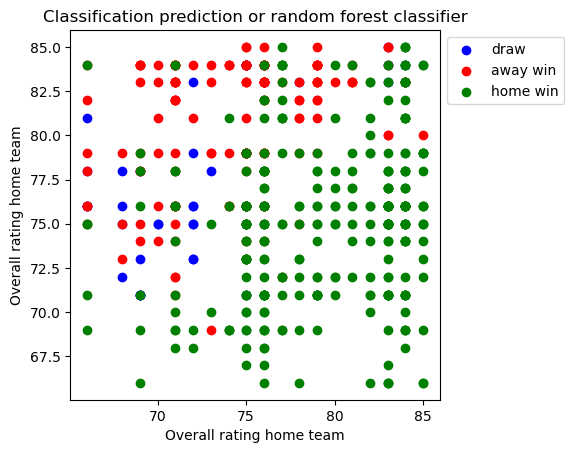

35


In [221]:
svm_ov_p = np.zeros((np.shape(euro_svm.X_test)[0], 2))
svm_ov_p[:,0] = euro_svm.X_test[:,0]
svm_ov_p[:,1] = euro_svm.X_test[:,7]
#svm_ov_and_labels[:,2] = euro_svm.labels_train

blue_dots_p = svm_ov_p[rf_clf.predict(euro_svm.X_test) == 0]
green_dots_p = svm_ov_p[rf_clf.predict(euro_svm.X_test) == 1]
red_dots_p = svm_ov_p[rf_clf.predict(euro_svm.X_test) == 2]

print(len(red_dots_p)+len(green_dots_p) + len(blue_dots_p))
plt.scatter(blue_dots_p[:,0],blue_dots_p[:,1], c = 'b', label = 'draw')
plt.scatter(red_dots_p[:,0], red_dots_p[:,1], c = 'r', label = 'away win')
plt.scatter(green_dots_p[:,0], green_dots_p[:,1], c = 'g', label = 'home win')
plt.title('Classification prediction or random forest classifier')
plt.xlabel('Overall rating home team')
plt.ylabel('Overall rating home team')
plt.legend(bbox_to_anchor=(1, 1))
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.show()


print(len(blue_dots_p))

499


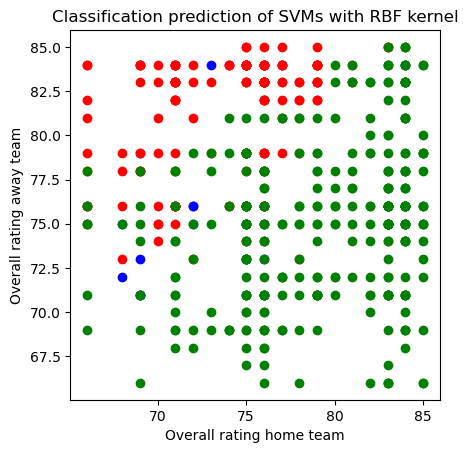

14


In [222]:
svm_ov_p = np.zeros((np.shape(euro_svm.X_test)[0], 2))
svm_ov_p[:,0] = euro_svm.X_test[:,0]
svm_ov_p[:,1] = euro_svm.X_test[:,7]
#svm_ov_and_labels[:,2] = euro_svm.labels_train

blue_dots_p = svm_ov_p[clf.predict(euro_svm.X_test) == 0]
green_dots_p = svm_ov_p[clf.predict(euro_svm.X_test) == 1]
red_dots_p = svm_ov_p[clf.predict(euro_svm.X_test) == 2]

print(len(red_dots_p)+len(green_dots_p) + len(blue_dots_p))
plt.scatter(blue_dots_p[:,0],blue_dots_p[:,1], c = 'b', label = 'draw')
plt.scatter(red_dots_p[:,0], red_dots_p[:,1], c = 'r', label = 'away win')
plt.scatter(green_dots_p[:,0], green_dots_p[:,1], c = 'g', label = 'home win')
plt.title('Classification prediction of SVMs with RBF kernel')
plt.xlabel('Overall rating home team')
plt.ylabel('Overall rating away team')
#plt.legend(bbox_to_anchor=(1, 1))
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.show()
print(len(blue_dots_p))

In [19]:
# here we create the group stage matches
def create_matches(ratings, matches):
        rated_matches = np.zeros((np.shape(matches)[0], 15))
        #print(np.shape(matches)[0])
        for row in range(0, np.shape(matches)[0]):
            ij = matches[row, 0:2]
            #print(ij)
            ratings_ij = list(ratings[int(ij[0]), 1:]) + list(ratings[int(ij[1]), 1:])
            ratings_ij.append(matches[row, -1]) # value 0/1 if played on neutral ground FALSE/TRUE
            ratings_ij = np.asarray(ratings_ij)
            #print(np.shape(ratings_ij))
            rated_matches[row] = ratings_ij # ratings of the teams of the corresponding result
        return rated_matches

In [20]:
# Training and prediction using least squares linear regression 

euro_np = Euro2024_new(np_team_ratings,np_results_wc_eu)
euro_np.create_X()
euro_np.data_split_np()
reg = LinearRegression().fit(euro_np.X_train, euro_np.Y_train)
y_pred_reg = reg.predict(euro_np.X_test)
loss_linreg = mse(euro_np.Y_test, y_pred_reg)
print(f'mean squared loss: {loss_linreg}')
matches_to_pred = create_matches(np_team_ratings, np_results_to_predict)
predicted_matches = reg.predict(matches_to_pred)
#print(f'predicted scores of EURO 2024 group stage matches: {predicted_matches}')
predicted_results = results_to_predict
predicted_results.loc[:, 'home_score'] = np.transpose(predicted_matches)[0]
predicted_results.loc[:, 'away_score'] = np.transpose(predicted_matches)[1]
predicted_results

mean squared loss: 1.4775259621802528


NameError: name 'np_results_to_predict' is not defined

In [83]:
goal_diff = np.zeros(36)
for i in range(len(goal_diff)):
    goal_diff[i] = predicted_matches[i,0]- predicted_matches[i,1]

goal_diff_round = np.around(goal_diff)
print(goal_diff)
goal_diff_round

[ 1.53240339 -0.27845181  0.50114909  1.74708016 -0.51027808 -0.99417254
 -0.64681395 -0.69930777 -0.37825275  0.84656563  0.48490069  0.83061996
  1.69997328 -0.13811514  1.32252556  0.13609019 -0.30272768 -0.43272885
 -0.19218656  0.00853226 -0.70458312  0.90562139 -0.78591549 -0.69722431
  1.50014416  0.06171399 -1.69985635 -0.28430942  1.00863612  0.26660382
  0.60363397  1.00240653 -0.24729038 -0.36974627 -1.47280538  0.07977656]


array([ 2., -0.,  1.,  2., -1., -1., -1., -1., -0.,  1.,  0.,  1.,  2.,
       -0.,  1.,  0., -0., -0., -0.,  0., -1.,  1., -1., -1.,  2.,  0.,
       -2., -0.,  1.,  0.,  1.,  1., -0., -0., -1.,  0.])

In [21]:
def rounded_results(match_res, diff, rounded_diff):
    rounded_result = np.asarray([0,0])
    coin = np.random.binomial(1,1/2)
    if coin == 0:
        if diff < 0:
            min_goal = np.min(match_res)
            home_goal = np.around(min_goal)
            away_goal = abs(rounded_diff) + home_goal
            rounded_result = np.asarray([home_goal, away_goal])
        if diff > 0:
            min_goal = np.min(match_res)
            away_goal = np.around(min_goal)
            home_goal = rounded_diff + away_goal
            rounded_result = np.asarray([home_goal, away_goal])
    if coin == 1:
        #if diff < 0:
        #    max_goal = np.max(match_res)
        #    away_goal = np.around(min_goal)
        #    away_goal = rounded_diff + away_goal
        #    rounded_result = np.asarray([home_goal, away_goal])
        #if diff > 0:
        #    min_goal = np.min(match_res)
        #    away_goal = np.around(min_goal)
        #    home_goal = rounded_diff + away_goal
        #    rounded_result = np.asarray([home_goal, away_goal])
        if diff < 0:
            away_goal = np.around(match_res[1])
            home_goal = np.floor(match_res[0])
            rounded_result = np.asarray([home_goal, away_goal])
        if diff > 0:
            away_goal = np.floor(match_res[1])
            home_goal = np.around(match_res[0])
            rounded_result = np.asarray([home_goal, away_goal])
            
    return rounded_result

In [84]:
results_groups_finally = np.zeros((36,2))
for i in range(len(predicted_matches)):
    results_groups_finally[i] = rounded_results(predicted_matches[i], goal_diff[i], goal_diff_round[i])

df_res_groups = predicted_results
df_res_groups.loc[:, 'home_score'] = np.transpose(results_groups_finally)[0]
df_res_groups.loc[:, 'away_score'] = np.transpose(results_groups_finally)[1]
df_res_groups

,home_number,away_number,home_team,away_team,home_score,away_score,neutral
2492,2,16,Germany,Scotland,2.0,0.0,0
2493,21,39,Hungary,Switzerland,1.0,1.0,1
2494,5,9,Spain,Croatia,2.0,1.0,1
2495,4,59,Italy,Albania,3.0,1.0,1
2496,49,10,Slovenia,Denmark,1.0,2.0,1
2497,56,0,Serbia,England,0.0,2.0,1
2498,12,7,Poland,Netherlands,0.0,2.0,1
2499,31,1,Austria,France,1.0,2.0,1
2500,25,19,Romania,Ukraine,1.0,1.0,1
2501,8,58,Belgium,Slovakia,2.0,1.0,1


In [75]:
nations_A = ['Germany', 'Scotland', 'Hungary', 'Switzerland']
nations_B = ['Spain', 'Croatia', 'Italy', 'Albania']
nations_C = ['Slovenia', 'Denmark', 'Serbia', 'England']
nations_D = ['Netherlands', 'France', 'Poland', 'Austria']
nations_E = ['Ukraine', 'Slovakia', 'Belgium', 'Romania']
nations_F = ['Portugal', 'Czech Republic', 'Georgia', 'Turkey']
all_nations = nations_A + nations_B + nations_C + nations_D + nations_E + nations_F
groups = ['A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'C', 'C', 'C', 'C', 'D', 'D', 'D', 'D', 'E', 'E', 'E', 'E', 'F', 'F',
         'F', 'F']


In [86]:
team_stats = {}

group_info = {'Germany':"A", 'Scotland':"A", 'Hungary':"A", 'Switzerland':"A" , 'Spain':"B", 'Croatia':"B", 'Italy':"B", 'Albania':"B",'Slovenia':"C", 'Denmark':"C", 'Serbia':"C", 'England':"C", 'Netherlands':"D", 'France':"D", 'Poland':"D", 'Austria':"D", 'Ukraine':"E", 'Slovakia':"E", 'Belgium':"E", 'Romania':"E", 'Portugal':"F", 'Czech Republic':"F", 'Georgia':"F", 'Turkey':"F"}


# Function to update team stats
def update_team_stats(team,group, goals_scored, goals_conceded, points):
    if team not in team_stats:
        team_stats[team] = {"Group:":group, 'Points': 0, 'GoalsScored': 0, 'GoalsConceded': 0}
    team_stats[team]['Points'] += points
    team_stats[team]['GoalsScored'] += goals_scored
    team_stats[team]['GoalsConceded'] += goals_conceded

# Iterate through each match result
for index, row in df_res_groups.iterrows():
    home_team = row['home_team']
    away_team = row['away_team']
    home_goals = row['home_score']
    away_goals = row['away_score']
    
    home_group =group_info[home_team]
    away_group = group_info[away_team]
    
    if home_goals > away_goals:
        update_team_stats(home_team, home_group,home_goals, away_goals, 3)  # Home team wins
        update_team_stats(away_team,away_group, away_goals, home_goals, 0)  # Away team loses
    elif home_goals < away_goals:
        update_team_stats(home_team,home_group, home_goals, away_goals, 0)  # Home team loses
        update_team_stats(away_team,away_group, away_goals, home_goals, 3)  # Away team wins
    else:
        update_team_stats(home_team, home_group,home_goals, away_goals, 1)  # Draw
        update_team_stats(away_team, away_group, away_goals, home_goals, 1)  # Draw

# Convert team_stats dictionary to a DataFrame for easier viewing
team_stats_df = pd.DataFrame.from_dict(team_stats, orient='index')
team_stats_df['GoalDifference'] = team_stats_df['GoalsScored'] - team_stats_df['GoalsConceded']

# Sort the DataFrame by Points and Goal Difference
team_stats_df = team_stats_df.sort_values(by=["Group:",'Points', 'GoalDifference'], ascending=False)

print("\nPoints Table with Goal Difference:")
print(team_stats_df)


Points Table with Goal Difference:
               Group:  Points  GoalsScored  GoalsConceded  GoalDifference
Portugal            F       9          6.0            1.0             5.0
Czech Republic      F       4          3.0            4.0            -1.0
Turkey              F       2          3.0            4.0            -1.0
Georgia             F       1          2.0            5.0            -3.0
Belgium             E       7          5.0            3.0             2.0
Ukraine             E       5          4.0            3.0             1.0
Romania             E       2          3.0            4.0            -1.0
Slovakia            E       1          3.0            5.0            -2.0
Netherlands         D       7          5.0            2.0             3.0
France              D       7          5.0            3.0             2.0
Austria             D       1          3.0            5.0            -2.0
Poland              D       1          2.0            5.0            -3.0
En

# Round of 16

In [108]:
# here we create the round of 16 matches
data_16 = {
    "home_team": ["Spain", "Germany", "Portugal", "France", "Belgium", "Netherlands", "England", "Switzerland"],
    "away_team": ["Turkey", "Denmark", "Croatia", "Ukraine", "Serbia", "Czech Republic", "Romania", "Italy"],
    "home_score": [0, 0, 0, 0, 0, 0, 0, 0],
    "away_score": [0, 0, 0, 0, 0, 0, 0, 0],
    "neutral": [1,0,1,1,1,1,1,1]
}

df_16 = pd.DataFrame(data_16)

# Display the DataFrame
print(df_16)

results_to_predict_16 = df_16

     home_team       away_team  home_score  away_score  neutral
0        Spain          Turkey           0           0        1
1      Germany         Denmark           0           0        0
2     Portugal         Croatia           0           0        1
3       France         Ukraine           0           0        1
4      Belgium          Serbia           0           0        1
5  Netherlands  Czech Republic           0           0        1
6      England         Romania           0           0        1
7  Switzerland           Italy           0           0        1


In [92]:
#np array for the matches to predict in the round of 16
to_predict_16 = np.array([[5,40,1],[2,10,0],[3,9,1],[1,19,1],[8,56,1],[7,14,1],[0,25,1],[39,4,1]])


array([[ 5, 40,  1],
       [ 2, 10,  0],
       [ 3,  9,  1],
       [ 1, 19,  1],
       [ 8, 56,  1],
       [ 7, 14,  1],
       [ 0, 25,  1],
       [39,  4,  1]])

In [95]:
rated_matches_to_predict_16 = create_matches(np_team_ratings, to_predict_16)

In [101]:
predicted_matches_16 = reg.predict(rated_matches_to_predict_16)
predicted_matches_16

array([[1.85966846, 0.9870853 ],
       [2.02218873, 0.69268926],
       [1.5625432 , 1.00919978],
       [1.78821382, 0.87525774],
       [1.67199807, 1.25541325],
       [1.77305037, 1.02728337],
       [1.87289603, 0.67396072],
       [0.97116455, 1.5483301 ]])

In [104]:
goal_diff_16 = np.zeros(8)
for i in range(len(goal_diff_16)):
    goal_diff_16[i] = predicted_matches_16[i,0]- predicted_matches_16[i,1]

goal_diff_round_16 = np.around(goal_diff_16)
print(goal_diff_16)
goal_diff_round_16

[ 0.87258316  1.32949946  0.55334342  0.91295608  0.41658482  0.745767
  1.19893531 -0.57716555]


array([ 1.,  1.,  1.,  1.,  0.,  1.,  1., -1.])

In [105]:
results_16_finally = np.zeros((8,2))
for i in range(len(predicted_matches_16)):
    results_16_finally[i] = rounded_results(predicted_matches_16[i], goal_diff_16[i], goal_diff_round_16[i])

df_res_16 = df_16
df_res_16.loc[:, 'home_score'] = np.transpose(results_16_finally)[0]
df_res_16.loc[:, 'away_score'] = np.transpose(results_16_finally)[1]
df_res_16

,home_team,away_team,home_score,away_score,neutral
0,Spain,Turkey,2.0,0.0,1
1,Germany,Denmark,2.0,0.0,0
2,Portugal,Croatia,2.0,1.0,1
3,France,Ukraine,2.0,1.0,1
4,Belgium,Serbia,1.0,1.0,1
5,Netherlands,Czech Republic,2.0,1.0,1
6,England,Romania,2.0,0.0,1
7,Switzerland,Italy,0.0,2.0,1


In [256]:
decider(predicted_matches_16[5,0],predicted_matches_16[5,1])
print("Home team is:")
print(df_res_16["home_team"][4])

Home team wins the penalties!
Home team is:
Belgium


In [184]:
# This function decides in case of a tie who will win the penalties
def decider(home_score, away_score):
    if home_score > away_score:
        p = home_score/(home_score + away_score)
    if away_score > home_score:
        p = away_score/(home_score + away_score)
    
    X = np.random.binomial(1,p)
    
    if X == 1:
        print("Home team wins the penalties!")
    else:
        print("Away team wins the penalties!")
    return X


# Quarter Finals

In [185]:
# here we create the round of 16 matches
data_8 = {
    "home_team": ["Spain", "Portugal", "Belgium", "England"],
    "away_team": ["Germany", "France", "Netherlands","Italy"],
    "home_score": [0, 0, 0, 0],
    "away_score": [0, 0, 0, 0],
    "neutral": [1,1,1,1]
}

df_8 = pd.DataFrame(data_8)

# Display the DataFrame
print(df_8)

results_to_predict_8 = df_8

  home_team    away_team  home_score  away_score  neutral
0     Spain      Germany           0           0        1
1  Portugal       France           0           0        1
2   Belgium  Netherlands           0           0        1
3   England        Italy           0           0        1


In [239]:
#np array for the matches to predict in the round of 8
to_predict_8 = np.array([[2,5,0],[3,1,1],[8,7,1],[0,4,1]])


In [240]:
rated_matches_to_predict_8 = create_matches(np_team_ratings, to_predict_8)

In [241]:
predicted_matches_8 = reg.predict(rated_matches_to_predict_8)
predicted_matches_8

array([[1.8017476 , 0.88831111],
       [1.38309724, 1.28971202],
       [1.28442526, 1.41649884],
       [1.37124376, 1.25557845]])

In [215]:
goal_diff_8 = np.zeros(4)
for i in range(len(goal_diff_8)):
    goal_diff_8[i] = predicted_matches_8[i,0]- predicted_matches_8[i,1]

goal_diff_round_8 = np.around(goal_diff_8)
print(goal_diff_8)
goal_diff_round_8

[-0.09592286  0.09338522 -0.13207358  0.11566531]


array([-0.,  0., -0.,  0.])

In [243]:
results_8_finally = np.zeros((4,2))
#have to seperately add match with germany because result is flipped, as we want to use neutral ground
results_8_finally[0] = [1,2]
for i in range(1,len(predicted_matches_8)):
    results_8_finally[i] = rounded_results(predicted_matches_8[i], goal_diff_8[i], goal_diff_round_8[i])

df_res_8 = df_8
df_res_8.loc[:, 'home_score'] = np.transpose(results_8_finally)[0]
df_res_8.loc[:, 'away_score'] = np.transpose(results_8_finally)[1]
df_res_8

,home_team,away_team,home_score,away_score,neutral
0,Spain,Germany,1.0,2.0,1
1,Portugal,France,1.0,1.0,1
2,Belgium,Netherlands,1.0,1.0,1
3,England,Italy,1.0,1.0,1


In [281]:
for i in range(1,len(predicted_matches_8)):
    decider(predicted_matches_8[i,0],predicted_matches_8[i,1])

Home team wins the penalties!
Away team wins the penalties!
Home team wins the penalties!


# Semi-finals

In [115]:
# here we create the round of 16 matches
data_4 = {
    "home_team": ["Germany", "Netherlands"],
    "away_team": ["Portugal", "England"],
    "home_score": [0, 0],
    "away_score": [0, 0],
    "neutral": [0,1]
}

df_4 = pd.DataFrame(data_4)

# Display the DataFrame
print(df_4)

results_to_predict_4 = df_4

     home_team away_team  home_score  away_score  neutral
0      Germany  Portugal           0           0        0
1  Netherlands   England           0           0        1


In [217]:
#np array for the matches to predict in the round of 4
to_predict_4 = np.array([[2,3,0],[7,0,1]])

In [218]:
rated_matches_to_predict_4 = create_matches(np_team_ratings, to_predict_4)

In [219]:
predicted_matches_4 = reg.predict(rated_matches_to_predict_4)
predicted_matches_4

array([[1.82957204, 0.93131004],
       [1.45378115, 1.45544884]])

In [283]:
goal_diff_4 = np.zeros(2)
for i in range(len(goal_diff_4)):
    goal_diff_4[i] = predicted_matches_4[i,0]- predicted_matches_4[i,1]

goal_diff_round_4 = np.around(goal_diff_4)
print(goal_diff_4)
goal_diff_round_4

[ 0.898262  -0.0016677]


array([ 1., -0.])

In [285]:
results_4_finally = np.zeros((2,2))

for i in range(0,len(predicted_matches_4)):
    results_4_finally[i] = rounded_results(predicted_matches_4[i], goal_diff_4[i], goal_diff_round_4[i])

df_res_4 = df_4
df_res_4.loc[:, 'home_score'] = np.transpose(results_4_finally)[0]
df_res_4.loc[:, 'away_score'] = np.transpose(results_4_finally)[1]
df_res_4

,home_team,away_team,home_score,away_score,neutral
0,Germany,Portugal,2.0,1.0,0
1,Netherlands,England,1.0,1.0,1


In [295]:
decider(predicted_matches_4[0,0],predicted_matches_4[0,1])
print("Away team is:")
print(df_res_4["away_team"][1])

Away team wins the penalties!
Away team is:
England


In [229]:
rated_matches_to_predict_final = create_matches(np_team_ratings, np.array([[2,0,1]]))
score_endgame = reg.predict(rated_matches_to_predict_final)
score_endgame

array([[1.68141728, 1.36702248]])

In [300]:
round_final = rounded_results(score_endgame[0] , score_endgame[0,0]-score_endgame[0,1], 0)
print(round_final)

[2. 1.]


In [302]:
print(f"The score of the final Germany - England is {int(round_final[0])}:{int(round_final[1])}! ")
print("The winner of the UEFA Euro 2024 is Germany!")

The score of the final Germany - England is 2:1! 
The winner of the UEFA Euro 2024 is Germany!


## Testing impact

In [31]:
#test impact of international prestige parameter on neutral ground
test_matches_p_1 = np.zeros((10, 15))

for i in range(10):
    test_matches_p_1[i] = np.asarray([90, 90, 90, 90, i, 25, 25, 65, 65, 65, 65, 1, 28, 28, 1])

test_results_p_1 = reg.predict(test_matches_p_1)
print(test_results_p_1)

[[1.37522417 0.69263703]
 [1.47949872 0.65914877]
 [1.58377327 0.62566051]
 [1.68804782 0.59217225]
 [1.79232237 0.55868399]
 [1.89659692 0.52519573]
 [2.00087147 0.49170747]
 [2.10514602 0.45821921]
 [2.20942057 0.42473095]
 [2.31369512 0.39124269]]


In [32]:
#test impact of international prestige parameter on biased ground
test_matches_p_0 = np.zeros((10, 15))

for i in range(10):
    test_matches_p_0[i] = np.asarray([90, 90, 90, 90, i, 25, 25, 65, 65, 65, 65, 1, 28, 28, 0])

test_results_p_0 = reg.predict(test_matches_p_0)
print(test_results_p_0)

[[1.54152762 0.37211585]
 [1.64580217 0.33862759]
 [1.75007672 0.30513933]
 [1.85435126 0.27165107]
 [1.95862581 0.23816281]
 [2.06290036 0.20467455]
 [2.16717491 0.17118629]
 [2.27144946 0.13769803]
 [2.37572401 0.10420976]
 [2.47999856 0.0707215 ]]


In [36]:
#test impact of rating on goal difference (neutral ground)
test_matches_r_1 = np.zeros((10, 15))

for i in range(10):
    test_matches_r_1[i] = np.asarray([50 + 5*i, 50 + 5*i, 50 + 5*i, 50 + 5*i, 5, 28, 28, 65, 65, 65, 65,5, 28, 28, 1])

test_results_r_1 = reg.predict(test_matches_r_1)
print(test_results_r_1)
test_diff_r_1 = np.asarray([test_results_r_1[i,0] - test_results_r_1[i,1] for i in range(10)])
print(test_diff_r_1)

[[0.95628572 1.56896277]
 [1.08828974 1.4562422 ]
 [1.22029376 1.34352164]
 [1.35229779 1.23080108]
 [1.48430181 1.11808051]
 [1.61630583 1.00535995]
 [1.74830986 0.89263939]
 [1.88031388 0.77991882]
 [2.0123179  0.66719826]
 [2.14432193 0.5544777 ]]
[-0.61267705 -0.36795246 -0.12322788  0.12149671  0.3662213   0.61094588
  0.85567047  1.10039506  1.34511964  1.58984423]


In [37]:
#test impact of rating on goal difference (biased ground)
test_matches_r_0 = np.zeros((10, 15))

for i in range(10):
    test_matches_r_0[i] = np.asarray([50 + 5*i, 50 + 5*i, 50 + 5*i, 50 + 5*i, 5, 28, 28, 65, 65, 65, 65,5, 28, 28, 0])

test_results_r_0 = reg.predict(test_matches_r_0)
print(test_results_r_0)
test_diff_r_0 = np.asarray([test_results_r_0[i,0] - test_results_r_0[i,1] for i in range(10)])
print(test_diff_r_0)

[[1.198586   1.26817755]
 [1.33059002 1.15545698]
 [1.46259404 1.04273642]
 [1.59459807 0.93001586]
 [1.72660209 0.81729529]
 [1.85860612 0.70457473]
 [1.99061014 0.59185417]
 [2.12261416 0.4791336 ]
 [2.25461819 0.36641304]
 [2.38662221 0.25369248]]
[-0.06959155  0.17513304  0.41985762  0.66458221  0.9093068   1.15403138
  1.39875597  1.64348056  1.88820515  2.13292973]


In [40]:
#test impact of age on goal difference (neutral ground)
test_matches_a_1 = np.zeros((10, 15))

for i in range(10):
    test_matches_a_1[i] = np.asarray([65,65, 65, 65, 5, 20 + 2*i, 20 + 2*i, 65, 65, 65, 65,5, 28, 28, 1])

test_results_a_1 = reg.predict(test_matches_a_1)
print(test_results_a_1)
test_diff_a_1 = np.asarray([test_results_a_1[i,0] - test_results_a_1[i,1] for i in range(10)])
print(test_diff_a_1)

[[0.63920815 1.26437214]
 [0.81748056 1.25597938]
 [0.99575297 1.24758661]
 [1.17402538 1.23919384]
 [1.35229779 1.23080108]
 [1.53057019 1.22240831]
 [1.7088426  1.21401554]
 [1.88711501 1.20562278]
 [2.06538742 1.19723001]
 [2.24365983 1.18883724]]
[-0.62516399 -0.43849882 -0.25183364 -0.06516847  0.12149671  0.30816188
  0.49482706  0.68149223  0.86815741  1.05482258]


In [41]:
#test impact of age on goal difference (biased ground)
test_matches_a_0 = np.zeros((10, 15))

for i in range(10):
    test_matches_a_0[i] = np.asarray([65,65, 65, 65, 5, 20 + 2*i, 20 + 2*i, 65, 65, 65, 65,5, 28, 28, 0])

test_results_a_0 = reg.predict(test_matches_a_0)
print(test_results_a_0)
test_diff_a_0 = np.asarray([test_results_a_0[i,0] - test_results_a_0[i,1] for i in range(10)])
print(test_diff_a_0)

[[0.88150843 0.96358692]
 [1.05978084 0.95519416]
 [1.23805325 0.94680139]
 [1.41632566 0.93840862]
 [1.59459807 0.93001586]
 [1.77287048 0.92162309]
 [1.95114289 0.91323032]
 [2.12941529 0.90483756]
 [2.3076877  0.89644479]
 [2.48596011 0.88805202]]
[-0.08207849  0.10458669  0.29125186  0.47791704  0.66458221  0.85124739
  1.03791256  1.22457774  1.41124291  1.59790809]


In [71]:
slope_p = (test_diff_p_1[-1] - test_diff_p_1[0])/9
print(f'the slope of the international prestige parameter is: {slope_p}')
slope_r = (test_diff_r_1[-1] - test_diff_r_1[0])/50
print(f'the slope of the overall rating parameter is: {slope_r}')
slope_a = (test_diff_a_1[-1] - test_diff_a_1[0])/18
print(f'the slope of the age parameters is: {slope_a}')

the slope of the international prestige parameter is: 0.1292762148037577
the slope of the overall rating parameter is: 0.044050425625635464
the slope of the age parameters is: 0.09333258749728096


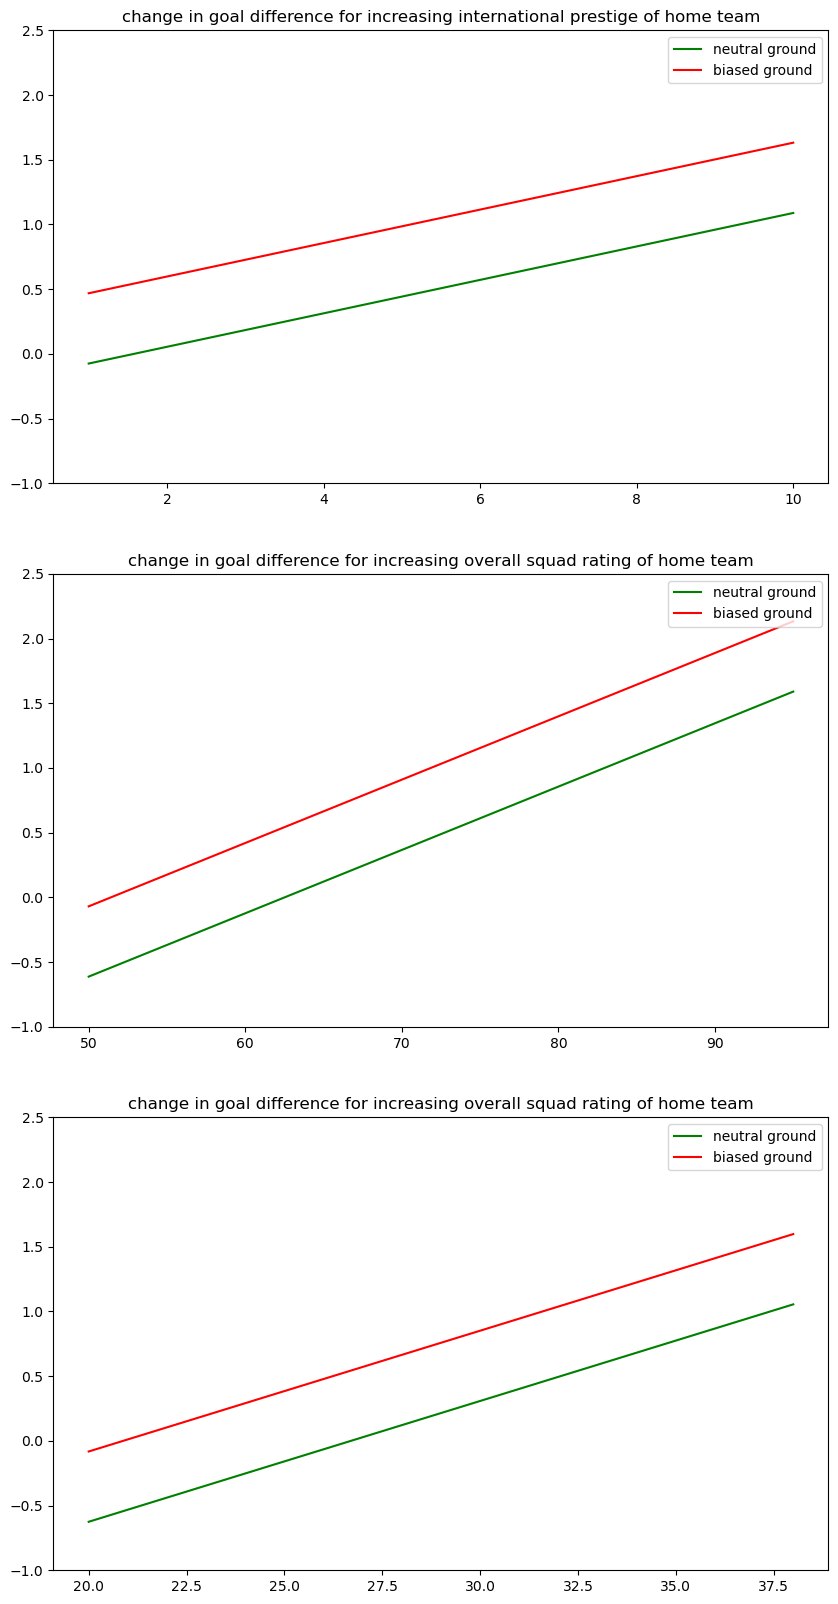

In [72]:
fig, ax = plt.subplots(nrows = 3, ncols = 1, figsize = (10,20))


ax[0].plot(np.asarray(range(1,11)), test_diff_p_1, color = 'g', label = 'neutral ground')
ax[0].plot(np.asarray(range(1,11)), test_diff_p_0, color = 'r', label = 'biased ground')
ax[0].set_title('change in goal difference for increasing international prestige of home team')
ax[0].set_ylim([-1,2.5])
ax[0].legend(loc = 'upper right')

ax[1].plot(np.asarray([50 + 5*i for i in range(10)]), test_diff_r_1, color = 'g', label = 'neutral ground')
ax[1].plot(np.asarray([50 + 5*i for i in range(10)]), test_diff_r_0, color = 'r', label = 'biased ground')
ax[1].set_title('change in goal difference for increasing overall squad rating of home team')
ax[1].set_ylim([-1,2.5])
ax[1].legend(loc = 'upper right')

ax[2].plot(np.asarray([20 + 2*i for i in range(10)]), test_diff_a_1, color = 'g', label = 'neutral ground')
ax[2].plot(np.asarray([20 + 2*i for i in range(10)]), test_diff_a_0, color = 'r', label = 'biased ground')
ax[2].set_title('change in goal difference for increasing overall squad rating of home team')
ax[2].set_ylim([-1,2.5])
ax[2].legend(loc = 'upper right')


plt.show()